# Convolutional Neural Network

Notebook eksperimen CNN untuk klasifikasi gambar Intel Image Classification.

- 16 variasi arsitektur Conv2D (shared parameter)
- Perbandingan shared vs non-shared (LocallyConnected2D)
- Perbandingan Keras vs from scratch
- Evaluasi dengan macro F1-score

## Bagian 1: Utility Functions & Data Loading

Implementasi utility functions untuk pemrosesan data image menggunakan PIL/Pillow dan NumPy.
- **Image loader**: load gambar, resize, normalisasi ke [0, 1]
- **Batch loader**: load sekumpulan gambar ke numpy array (N, H, W, C)
- **Feature extractor**: ekstraksi feature vectors menggunakan pretrained CNN

### Import Libraries

In [9]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

import tensorflow as tf
import numpy as np
from sklearn.metrics import f1_score, classification_report
from tqdm import tqdm
import json

from src.cnn.config import get_all_configs
from src.cnn.training import (
    prepare_datasets,
    train_single_model,
    evaluate_model,
    save_evaluation,
    run_all_experiments,
    find_best_config,
    train_locally_connected,
    load_all_results,
)
from src.cnn.visualization import (
    plot_loss_curves,
    plot_all_loss_curves,
    plot_hyperparameter_effect,
    plot_all_hyperparameter_effects,
    plot_f1_ranking,
    plot_shared_vs_nonshared,
    plot_keras_vs_scratch,
    plot_confusion_matrix,
    plot_loss_by_hyperparameter,
)
from src.cnn.weight_loader_cnn import build_scratch_from_keras, build_scratch_local_from_keras
from src.common.image_utils import load_image, load_images, list_image_paths_by_class

Project root: d:\CompSCI_ITB\Materi\Semester_6\ML\Tubes\Tubes2\Tugas-Besar-ML-2


### Load Dataset

Dataset: Intel Image Classification (6 kelas: buildings, forest, glacier, mountain, sea, street).

In [10]:
TRAIN_DIR = PROJECT_ROOT / "data/raw/intel_image_classification/seg_train"
TEST_DIR  = PROJECT_ROOT / "data/raw/intel_image_classification/seg_test"

train_ds, val_ds, test_ds, class_names = prepare_datasets(
    TRAIN_DIR, TEST_DIR, img_size=(150, 150), batch_size=32
)
print("Classes:", class_names)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [11]:
test_paths, test_labels, class_names = list_image_paths_by_class(TEST_DIR)

print("Jumlah test image:", len(test_paths))
print("Class names:", class_names)

from collections import Counter
print(Counter(test_labels))

Jumlah test image: 3000
Class names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Counter({2: 553, 3: 525, 4: 510, 5: 501, 1: 474, 0: 437})


## Bagian 2: Implementasi Forward Propagation From Scratch

Layer yang diimplementasikan secara modular (setiap layer punya method `forward`):
- **Conv2D** (shared parameters): operasi konvolusi 2D dengan sliding filter
- **LocallyConnected2D** (non-shared parameters): konvolusi tanpa parameter sharing
- **MaxPooling2D / AveragePooling2D**: sliding window pooling
- **GlobalAveragePooling2D / GlobalMaxPooling2D**: reduksi spasial
- **Flatten**: reshape tensor ke vektor 1D
- **Dense**: fully connected layer (dari Tubes 1)
- **Aktivasi**: ReLU, Softmax

Implementasi ada di modul `src/cnn/scratch_layers_cnn.py`, `src/common/dense.py`, dan `src/common/activations.py`.

Weight loader di `src/cnn/weight_loader_cnn.py` membaca bobot dari model Keras untuk validasi output scratch.

### Demonstrasi Forward Pass From Scratch

Demonstrasi bahwa implementasi from scratch menghasilkan output yang konsisten dengan Keras.

In [12]:
# Demo: load satu gambar dan bandingkan output Keras vs Scratch
demo_img = load_image(test_paths[0], target_size=(150, 150))
print("Shape gambar:", demo_img.shape)
print("Range pixel:", demo_img.min(), "-", demo_img.max())

# Load baseline model (Conv2D shared, 2 layer, 32-64, kernel 3, max pool)
from src.cnn.keras_models import build_baseline_cnn
baseline_path = PROJECT_ROOT / "models/cnn/baseline_conv2d.keras"
if baseline_path.exists():
    baseline_keras = tf.keras.models.load_model(str(baseline_path))
    baseline_scratch = build_scratch_from_keras(str(baseline_path), {
        "conv_layers": 2, "kernel_sizes": [3, 3], "pooling": "max"
    })
    
    # Keras prediction
    keras_out = baseline_keras.predict(demo_img[np.newaxis], verbose=0)
    
    # Scratch prediction
    scratch_out = baseline_scratch.forward(demo_img[np.newaxis])
    
    print("\nKeras output :", keras_out[0][:6])
    print("Scratch output:", scratch_out[0][:6])
    print("Max diff      :", np.max(np.abs(keras_out - scratch_out)))
    print("\n✓ Output Keras dan from scratch konsisten!" if np.allclose(keras_out, scratch_out, atol=1e-5) else "✗ Ada perbedaan signifikan!")
else:
    print("Baseline model belum ada, akan dibuat setelah training.")

Shape gambar: (150, 150, 3)
Range pixel: 0.0 - 1.0

Keras output : [9.9880373e-01 3.6892703e-07 9.0987998e-04 1.0320279e-07 2.1174617e-04
 7.4219613e-05]
Scratch output: [9.98803735e-01 3.68929818e-07 9.09891678e-04 1.03202595e-07
 2.11750244e-04 7.42196862e-05]
Max diff      : 1.169974e-08

✓ Output Keras dan from scratch konsisten!


## Bagian 3: Pelatihan Model CNN

16 variasi arsitektur Conv2D (shared parameter):
- **Jumlah conv layer**: 2 variasi (2, 3)
- **Banyak filter**: 2 variasi ([32,64], [64,128])
- **Ukuran kernel**: 2 variasi (3, 5)
- **Jenis pooling**: 2 variasi (max, average)

Total = 2 × 2 × 2 × 2 = **16 arsitektur**

**Loss**: Sparse Categorical Crossentropy | **Optimizer**: Adam | **Metrik**: Macro F1-Score

### Konfigurasi Eksperimen

In [13]:
configs = get_all_configs()

print(f"Total konfigurasi: {len(configs)}\n")
for i, cfg in enumerate(configs, 1):
    print(f"  {i:2d}. {cfg['name']}")

Total konfigurasi: 16

   1. conv2_filters_32-64_kernels_3-3_pool_max
   2. conv2_filters_32-64_kernels_3-3_pool_average
   3. conv2_filters_32-64_kernels_5-5_pool_max
   4. conv2_filters_32-64_kernels_5-5_pool_average
   5. conv2_filters_64-128_kernels_3-3_pool_max
   6. conv2_filters_64-128_kernels_3-3_pool_average
   7. conv2_filters_64-128_kernels_5-5_pool_max
   8. conv2_filters_64-128_kernels_5-5_pool_average
   9. conv3_filters_32-64-128_kernels_3-3-3_pool_max
  10. conv3_filters_32-64-128_kernels_3-3-3_pool_average
  11. conv3_filters_32-64-128_kernels_5-5-5_pool_max
  12. conv3_filters_32-64-128_kernels_5-5-5_pool_average
  13. conv3_filters_64-128-256_kernels_3-3-3_pool_max
  14. conv3_filters_64-128-256_kernels_3-3-3_pool_average
  15. conv3_filters_64-128-256_kernels_5-5-5_pool_max
  16. conv3_filters_64-128-256_kernels_5-5-5_pool_average


### Training Semua 16 Konfigurasi

Training otomatis skip model yang sudah ada (`force=False`).

In [14]:
all_results = run_all_experiments(
    configs,
    train_ds, val_ds, test_ds,
    class_names=class_names,
    epochs=10,
    models_dir=str(PROJECT_ROOT / "models/cnn"),
    results_dir=str(PROJECT_ROOT / "results/cnn"),
    force=False,
)


############################################################
# Experiment 1/16: conv2_filters_32-64_kernels_3-3_pool_max
############################################################
[SKIP] conv2_filters_32-64_kernels_3-3_pool_max — model & history sudah ada. Gunakan force=True untuk retrain.
[SAVED] Metrics → d:\CompSCI_ITB\Materi\Semester_6\ML\Tubes\Tubes2\Tugas-Besar-ML-2\results\cnn\conv2_filters_32-64_kernels_3-3_pool_max_metrics.json
  Macro F1 : 0.7663
  Accuracy : 0.7640
  Params   : 11,235,142


############################################################
# Experiment 2/16: conv2_filters_32-64_kernels_3-3_pool_average
############################################################
[SKIP] conv2_filters_32-64_kernels_3-3_pool_average — model & history sudah ada. Gunakan force=True untuk retrain.
[SAVED] Metrics → d:\CompSCI_ITB\Materi\Semester_6\ML\Tubes\Tubes2\Tugas-Besar-ML-2\results\cnn\conv2_filters_32-64_kernels_3-3_pool_average_metrics.json
  Macro F1 : 0.7561
  Accuracy : 0.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 150, 150, 64)   │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (AveragePooling2D)        │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 75, 75, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (AveragePooling2D)        │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 175232)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │    22,429,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,640,390 (86.37 MB)

 Trainable params: 22,640,390 (86.37 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 150, 150, 64)   │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (AveragePooling2D)        │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 75, 75, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (AveragePooling2D)        │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 37, 37, 256)    │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (AveragePooling2D)        │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │    10,616,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,646,982 (44.43 MB)

 Trainable params: 11,646,982 (44.43 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 394s 1s/step - accuracy: 0.5460 - loss: 1.1433 - val_accuracy: 0.6172 - val_loss: 0.9645
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 392s 1s/step - accuracy: 0.6556 - loss: 0.9012 - val_accuracy: 0.6575 - val_loss: 0.9306
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 391s 1s/step - accuracy: 0.7339 - loss: 0.7052 - val_accuracy: 0.7662 - val_loss: 0.6606
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 393s 1s/step - accuracy: 0.7660 - loss: 0.6566 - val_accuracy: 0.7338 - val_loss: 0.7525
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 385s 1s/step - accuracy: 0.8212 - loss: 0.4845 - val_accuracy: 0.7609 - val_loss: 0.7028
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 881s 3s/step - accuracy: 0.8567 - loss: 0.3903 - val_accuracy: 0.8079 - val_loss: 0.6693
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 713s 2s/step - accuracy: 0.8965 - loss: 0.2917 - val_accuracy: 0.7947 - val_loss: 0.7400
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 404s 1s/step - accuracy: 0.9187 - loss: 0.2312 - val_accu

## Bagian 4: Eksperimen dan Evaluasi

### 4.1 Ringkasan Hasil Semua 16 Eksperimen

In [15]:
import pandas as pd

if not all_results or len(all_results) < len(configs):
    print("Loading results dari disk...")
    all_results = load_all_results(configs, results_dir=str(PROJECT_ROOT / "results/cnn"))
    print(f"Loaded {len(all_results)} results")

summary_data = []
for r in all_results:
    cfg = r["config"]
    summary_data.append({
        "Name": r["name"],
        "Conv Layers": cfg["conv_layers"],
        "Filters": str(cfg["filters"]),
        "Kernel Size": cfg["kernel_sizes"][0],
        "Pooling": cfg["pooling"],
        "Macro F1": f"{r['macro_f1']:.4f}",
        "Accuracy": f"{r['accuracy']:.4f}",
        "Params": f"{r['num_params']:,}",
    })

df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.sort_values("Macro F1", ascending=False).reset_index(drop=True)
df_summary.index += 1
df_summary.index.name = "Rank"
display(df_summary)

,Name,Conv Layers,Filters,Kernel Size,Pooling,Macro F1,Accuracy,Params
Rank,,,,,,,,
1,conv3_filters_32-64-128_kernels_3-3-3_pool_max,3,"[32, 64, 128]",3,max,0.7897,0.7900,"5,402,566"
2,conv3_filters_32-64-128_kernels_3-3-3_pool_ave...,3,"[32, 64, 128]",3,average,0.7890,0.7860,"5,402,566"
3,conv3_filters_64-128-256_kernels_5-5-5_pool_max,3,"[64, 128, 256]",5,max,0.7887,0.7857,"11,646,982"
4,conv3_filters_32-64-128_kernels_5-5-5_pool_max,3,"[32, 64, 128]",5,max,0.7862,0.7850,"5,567,942"
5,conv3_filters_64-128-256_kernels_3-3-3_pool_max,3,"[64, 128, 256]",3,max,0.7834,0.7820,"10,988,550"
6,conv2_filters_64-128_kernels_3-3_pool_max,2,"[64, 128]",3,max,0.7764,0.7750,"22,506,246"
7,conv3_filters_64-128-256_kernels_5-5-5_pool_av...,3,"[64, 128, 256]",5,average,0.7734,0.7727,"11,646,982"
8,conv3_filters_64-128-256_kernels_3-3-3_pool_av...,3,"[64, 128, 256]",3,average,0.7693,0.7673,"10,988,550"
9,conv2_filters_32-64_kernels_3-3_pool_max,2,"[32, 64]",3,max,0.7663,0.7640,"11,235,142"


### 4.2 Ranking Model berdasarkan Macro F1-Score

[SAVED] d:\CompSCI_ITB\Materi\Semester_6\ML\Tubes\Tubes2\Tugas-Besar-ML-2\results\cnn\f1_ranking.png


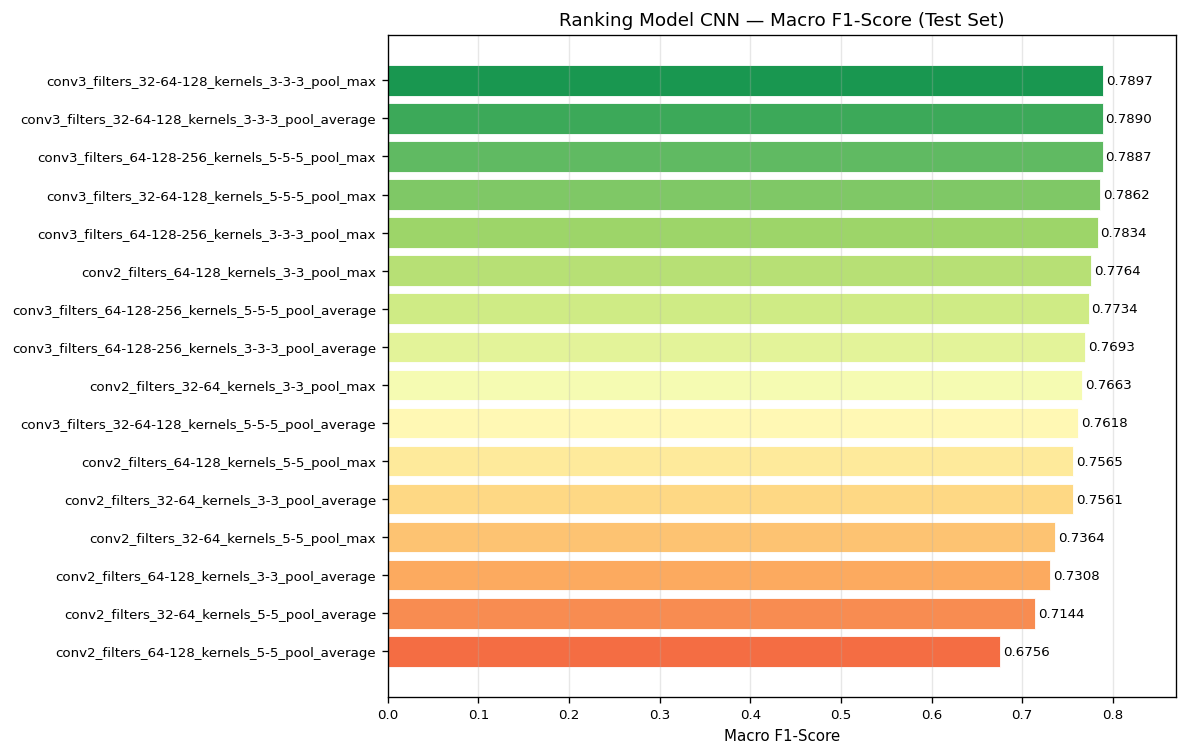

In [16]:
plot_f1_ranking(all_results, save_path=str(PROJECT_ROOT / "results/cnn/f1_ranking.png"))

### 4.3 Training vs Validation Loss — Semua Model

[SAVED] d:\CompSCI_ITB\Materi\Semester_6\ML\Tubes\Tubes2\Tugas-Besar-ML-2\results\cnn\all_loss_curves.png


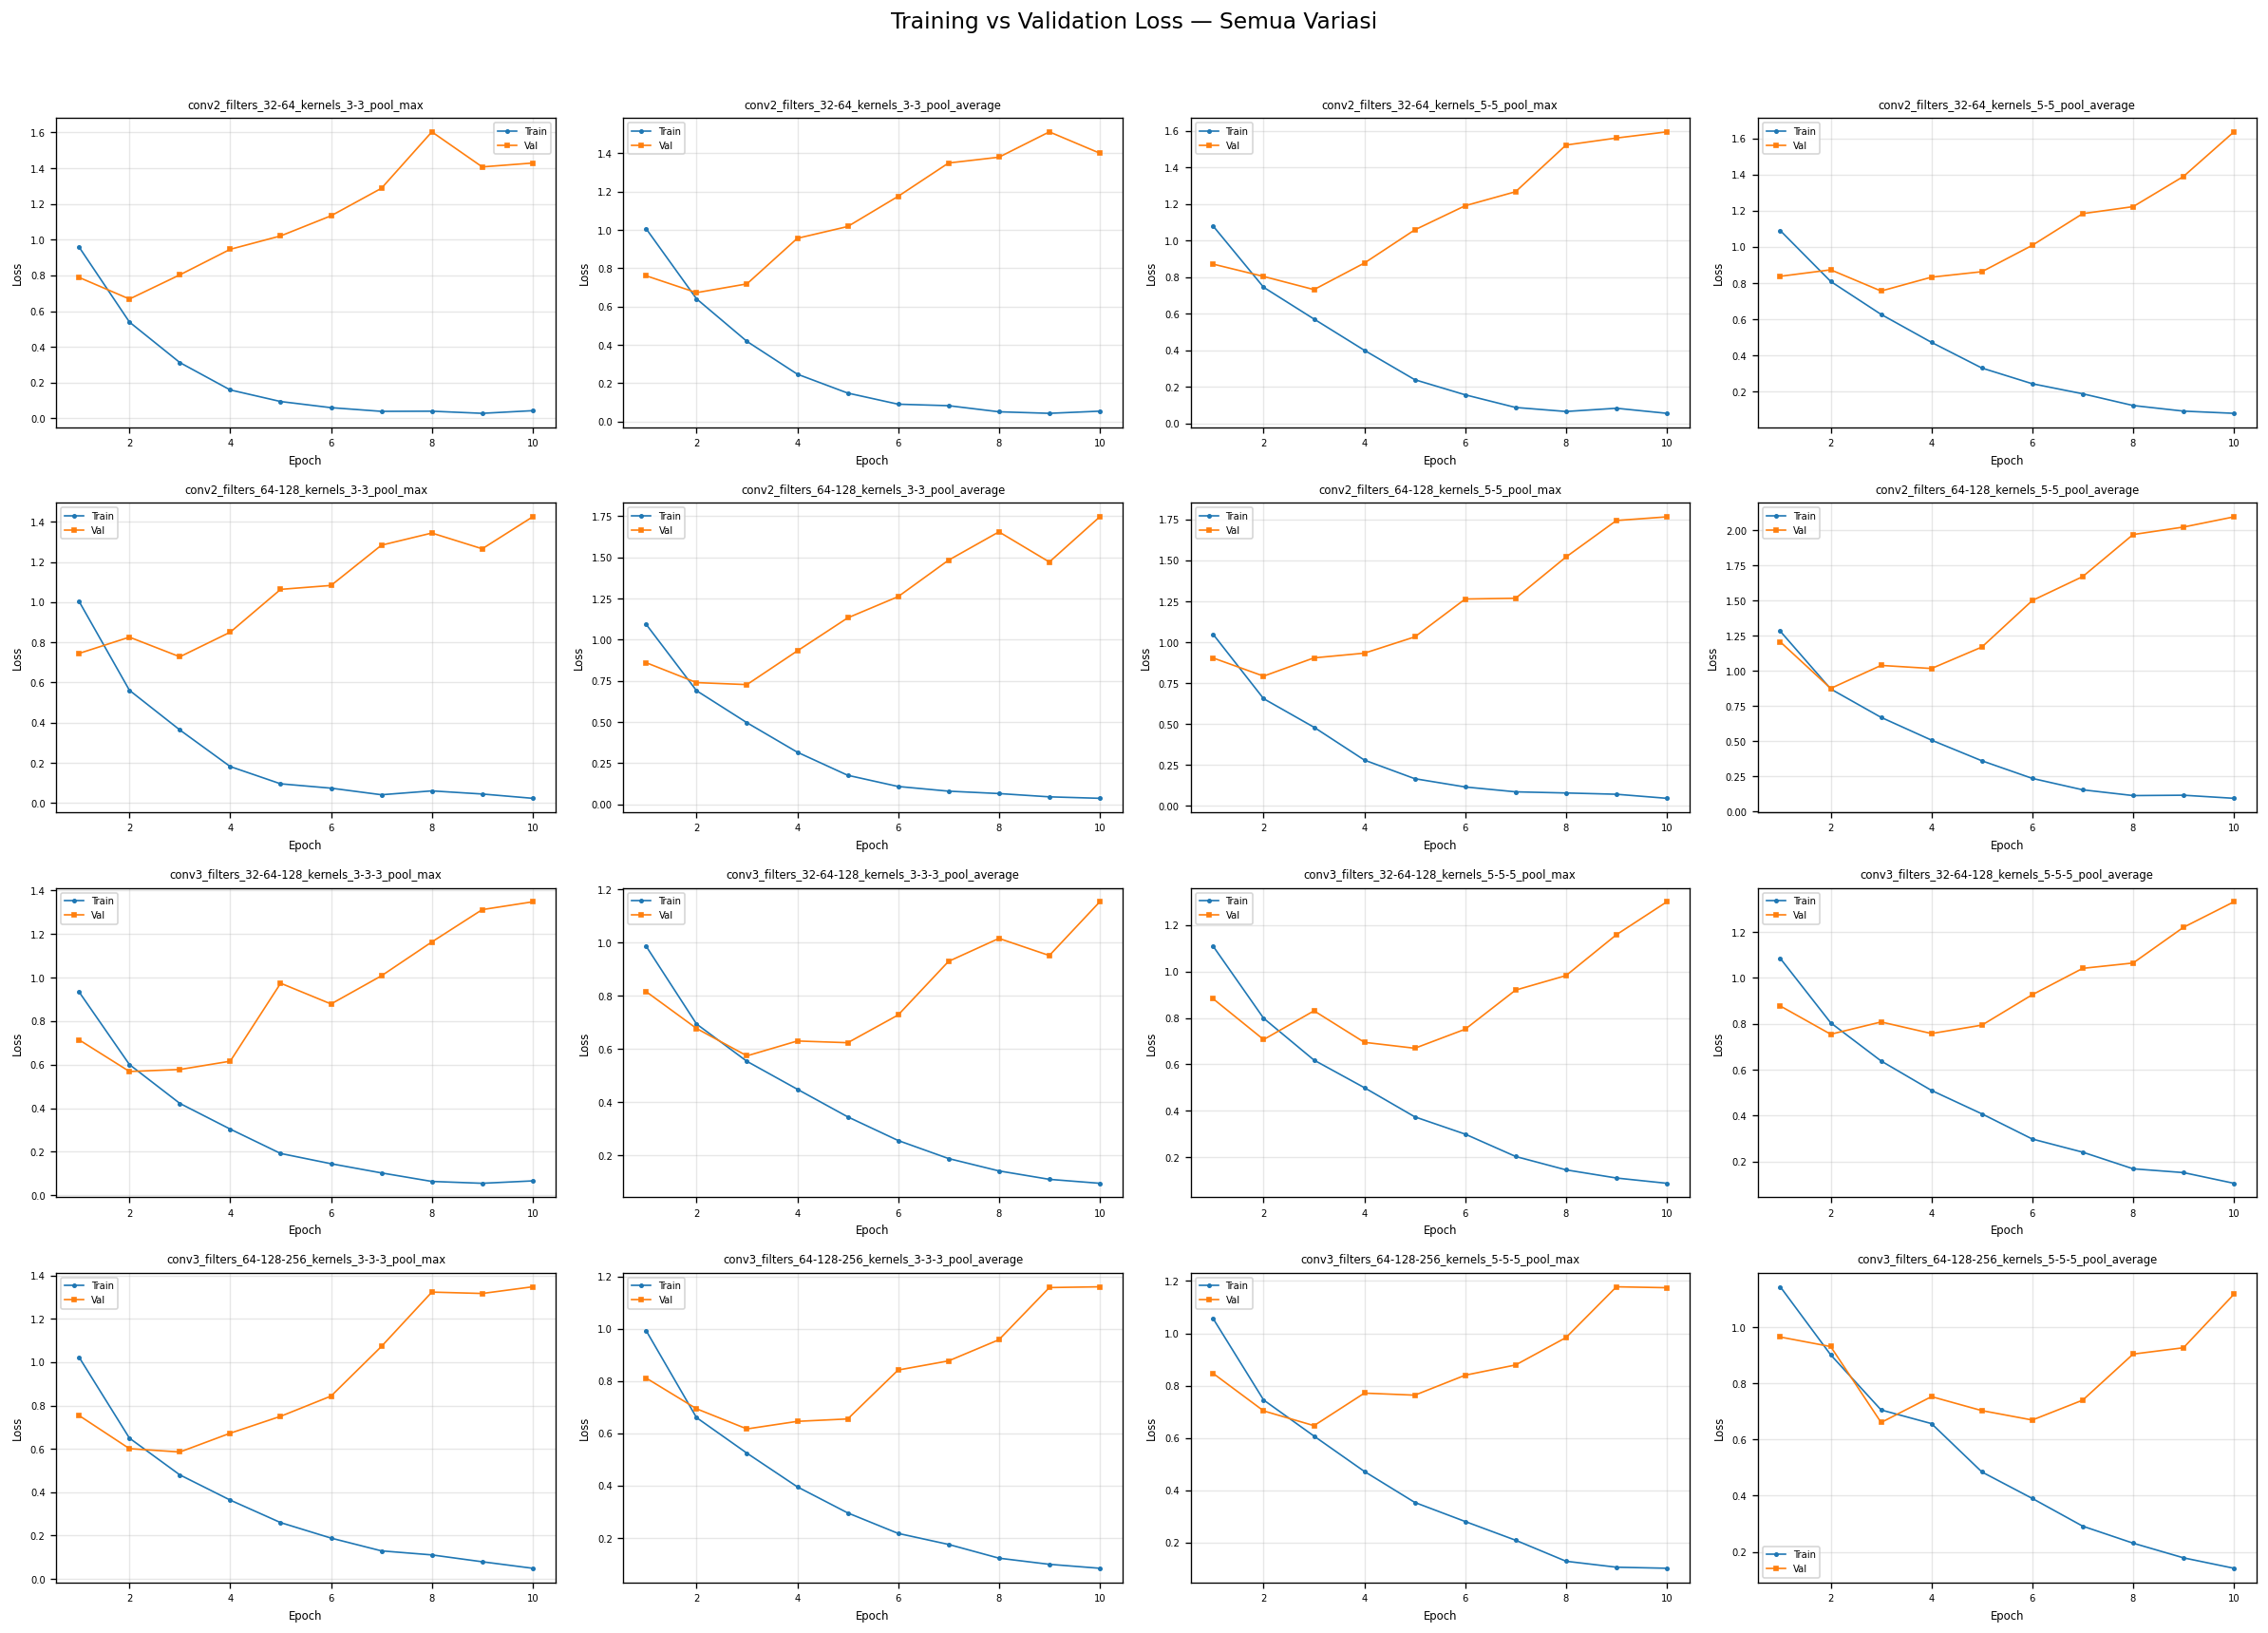

In [17]:
plot_all_loss_curves(all_results, save_path=str(PROJECT_ROOT / "results/cnn/all_loss_curves.png"))

### 4.4 Analisis Pengaruh Hyperparameter

Analisis pengaruh setiap hyperparameter terhadap macro F1-score.

[SAVED] d:\CompSCI_ITB\Materi\Semester_6\ML\Tubes\Tubes2\Tugas-Besar-ML-2\results\cnn\hyperparameter_effects.png


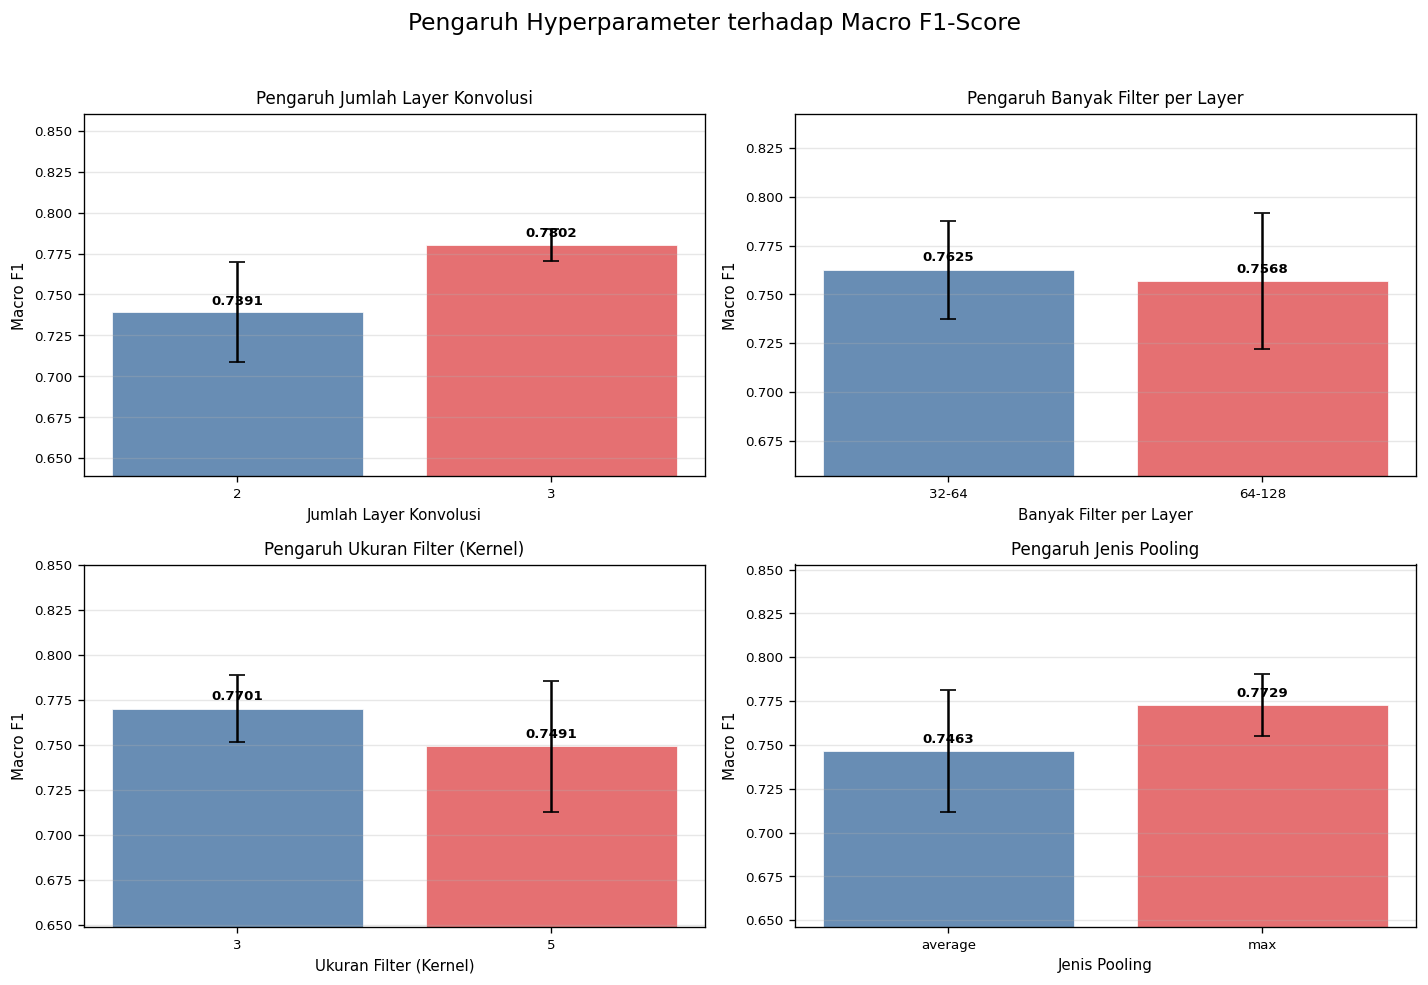

In [18]:
plot_all_hyperparameter_effects(all_results, save_dir=str(PROJECT_ROOT / "results/cnn"))

#### Validation Loss per Hyperparameter

[SAVED] d:\CompSCI_ITB\Materi\Semester_6\ML\Tubes\Tubes2\Tugas-Besar-ML-2\results\cnn\loss_by_conv_layers.png


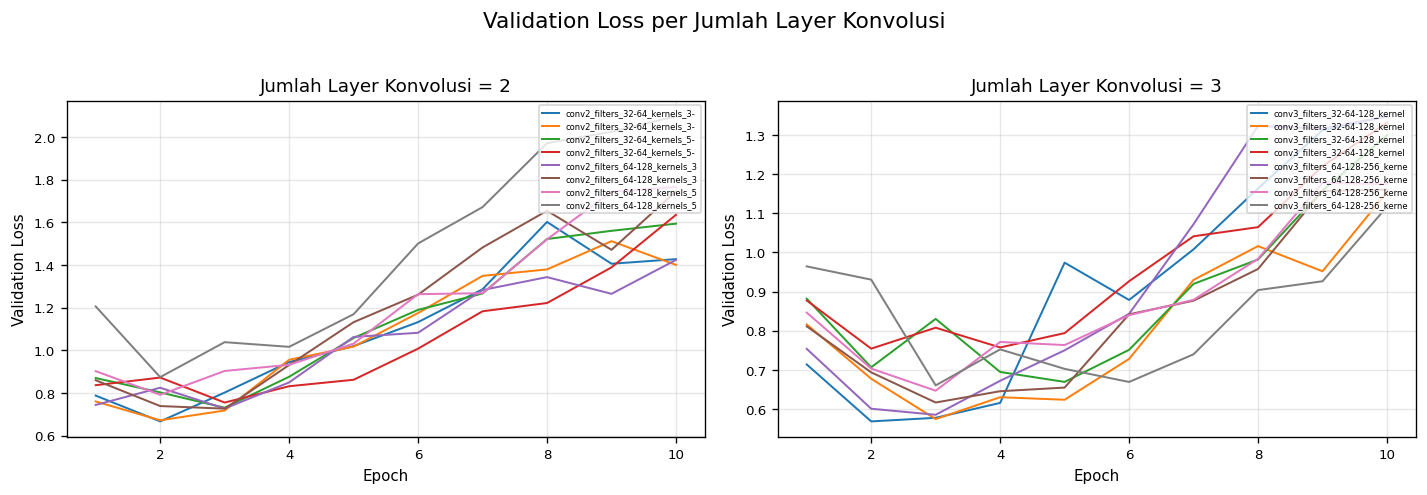

[SAVED] d:\CompSCI_ITB\Materi\Semester_6\ML\Tubes\Tubes2\Tugas-Besar-ML-2\results\cnn\loss_by_filters.png


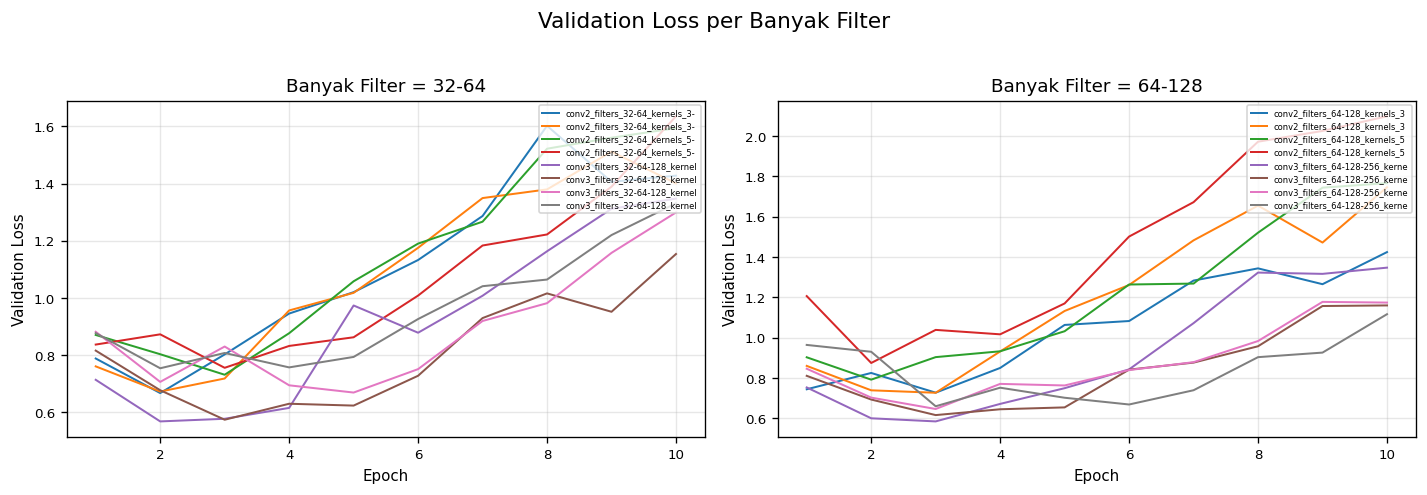

[SAVED] d:\CompSCI_ITB\Materi\Semester_6\ML\Tubes\Tubes2\Tugas-Besar-ML-2\results\cnn\loss_by_kernel_sizes.png


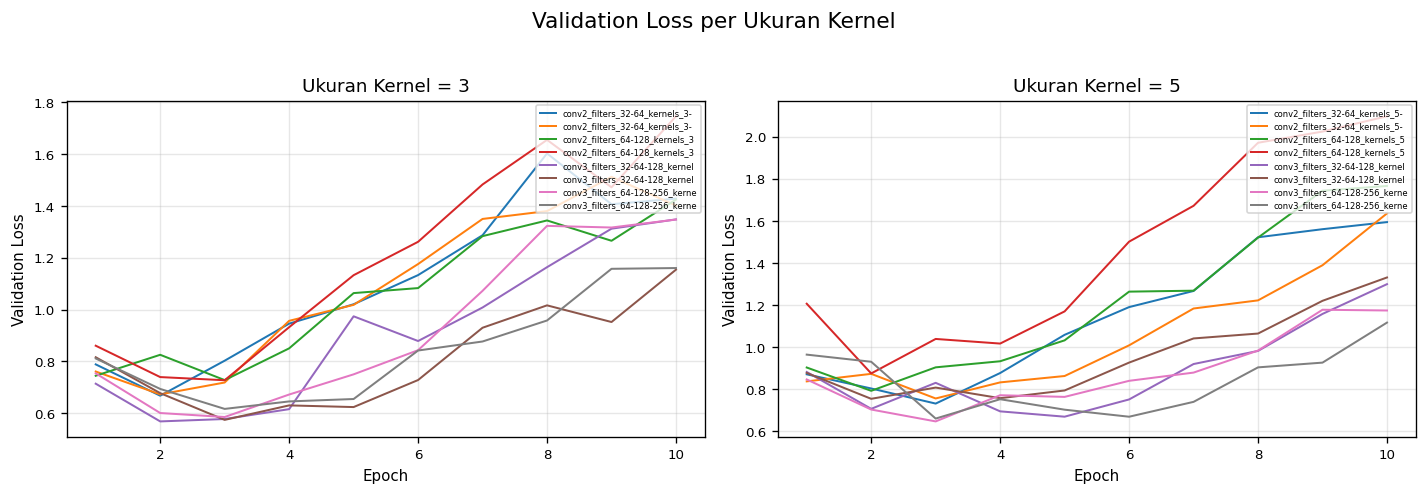

[SAVED] d:\CompSCI_ITB\Materi\Semester_6\ML\Tubes\Tubes2\Tugas-Besar-ML-2\results\cnn\loss_by_pooling.png


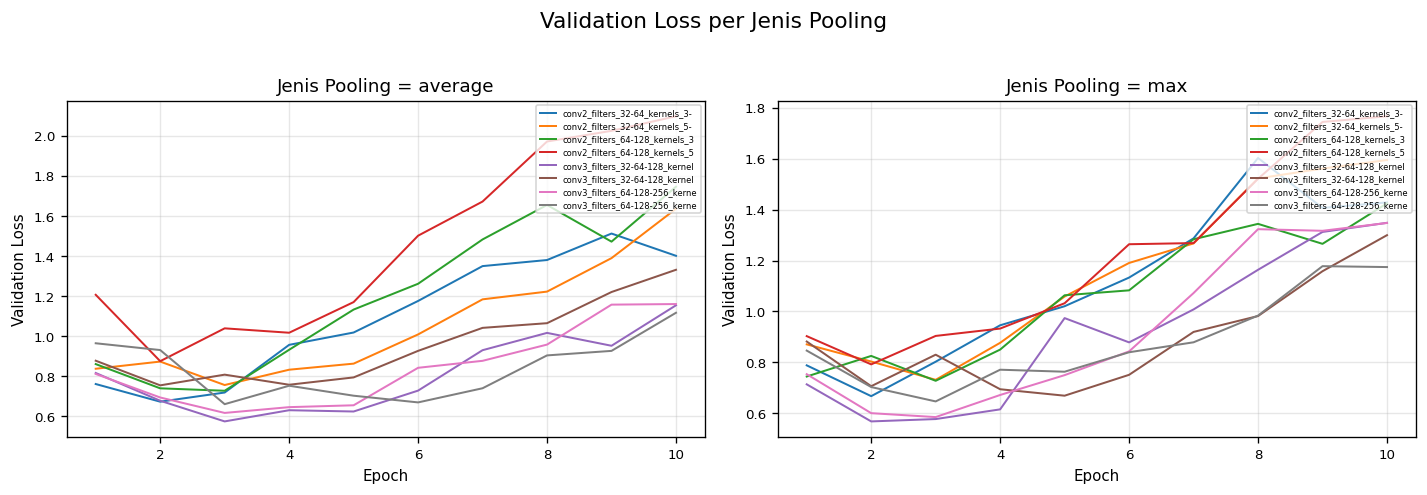

In [19]:
for param in ["conv_layers", "filters", "kernel_sizes", "pooling"]:
    plot_loss_by_hyperparameter(all_results, param, save_dir=str(PROJECT_ROOT / "results/cnn"))

#### Analisis Pengaruh Hyperparameter

**Pengaruh Jumlah Layer Konvolusi (2 vs 3)**:
- Menambah layer konvolusi memungkinkan model menangkap fitur yang lebih abstrak dan hierarkis.
- Namun, lebih banyak layer juga meningkatkan risiko overfitting pada dataset kecil.

**Pengaruh Banyak Filter (32-64 vs 64-128)**:
- Filter yang lebih banyak memberikan kapasitas representasi yang lebih tinggi.
- Trade-off: jumlah parameter meningkat signifikan, yang berdampak pada waktu training.

**Pengaruh Ukuran Kernel (3×3 vs 5×5)**:
- Kernel 3×3 menangkap fitur lokal yang lebih detail.
- Kernel 5×5 menangkap konteks spasial yang lebih luas dalam satu operasi.

**Pengaruh Jenis Pooling (Max vs Average)**:
- Max pooling mempertahankan fitur paling dominan (edge, texture).
- Average pooling memberikan representasi yang lebih halus dan merata.

### 4.5 Evaluasi Model Terbaik

In [20]:
best_config = find_best_config(all_results)
best_name = best_config["name"]
print(f"\nModel terbaik: {best_name}")

# Load metrics model terbaik
best_result = [r for r in all_results if r["name"] == best_name][0]
print(f"Macro F1: {best_result['macro_f1']:.4f}")
print(f"Accuracy: {best_result['accuracy']:.4f}")
print(f"Parameters: {best_result['num_params']:,}")

Best config: conv3_filters_32-64-128_kernels_3-3-3_pool_max (F1=0.7897)

Model terbaik: conv3_filters_32-64-128_kernels_3-3-3_pool_max
Macro F1: 0.7897
Accuracy: 0.7900
Parameters: 5,402,566


#### Classification Report — Model Terbaik

In [21]:
# Load predictions
y_true = np.load(str(PROJECT_ROOT / f"results/cnn/{best_name}_y_true.npy"))
y_pred = np.load(str(PROJECT_ROOT / f"results/cnn/{best_name}_y_pred.npy"))

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

              precision    recall  f1-score   support

   buildings       0.78      0.71      0.75       437
      forest       0.94      0.92      0.93       474
     glacier       0.84      0.62      0.71       553
    mountain       0.78      0.74      0.76       525
         sea       0.70      0.87      0.77       510
      street       0.75      0.90      0.82       501

    accuracy                           0.79      3000
   macro avg       0.80      0.79      0.79      3000
weighted avg       0.80      0.79      0.79      3000



#### Confusion Matrix — Model Terbaik

[SAVED] d:\CompSCI_ITB\Materi\Semester_6\ML\Tubes\Tubes2\Tugas-Besar-ML-2\results\cnn\confusion_matrix_best.png


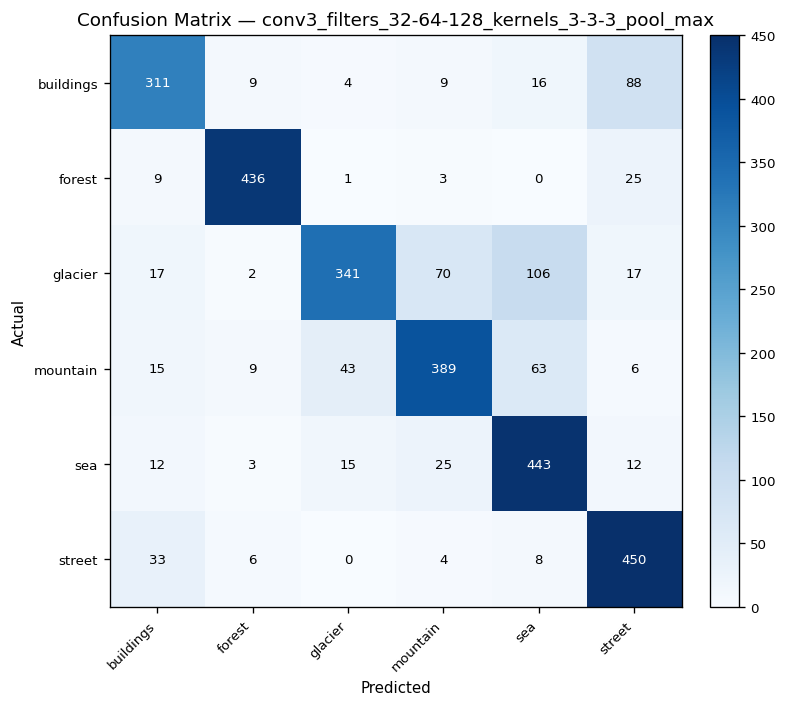

In [22]:
plot_confusion_matrix(
    best_result["confusion_matrix"],
    class_names=class_names,
    title=f"Confusion Matrix — {best_name}",
    save_path=str(PROJECT_ROOT / f"results/cnn/confusion_matrix_best.png"),
)

#### Training/Validation Loss — Model Terbaik

[SAVED] d:\CompSCI_ITB\Materi\Semester_6\ML\Tubes\Tubes2\Tugas-Besar-ML-2\results\cnn\loss_best.png


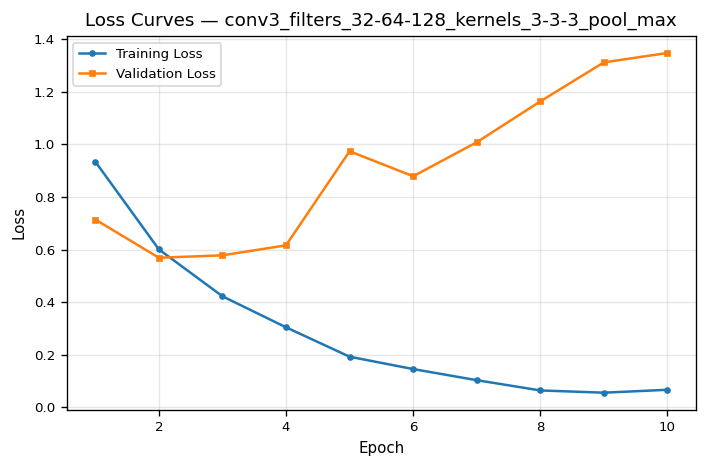

In [23]:
best_history = best_result.get("history")
if best_history:
    plot_loss_curves(best_history, title=f"Loss Curves — {best_name}",
                     save_path=str(PROJECT_ROOT / f"results/cnn/loss_best.png"))

### 4.6 Perbandingan Shared vs Non-Shared Parameter

Membandingkan arsitektur terbaik dengan versi non-shared (LocallyConnected2D):
- Macro F1-score
- Jumlah parameter
- Training/validation loss curves

In [24]:
# Train model non-shared (LocallyConnected2D) dengan config terbaik
local_model, local_history = train_locally_connected(
    best_config, train_ds, val_ds,
    epochs=10,
    models_dir=str(PROJECT_ROOT / "models/cnn"),
    results_dir=str(PROJECT_ROOT / "results/cnn"),
)

# Evaluasi non-shared pada test set
local_result = evaluate_model(local_model, test_ds, class_names)

# Simpan evaluasi non-shared
local_config_name = best_config.copy()
local_config_name["name"] = best_config["name"].replace("conv", "local")
save_evaluation(local_result, local_config_name, results_dir=str(PROJECT_ROOT / "results/cnn"))

print(f"\nShared (Conv2D):")
print(f"  Macro F1: {best_result['macro_f1']:.4f}, Params: {best_result['num_params']:,}")
print(f"\nNon-Shared (LocallyConnected2D):")
print(f"  Macro F1: {local_result['macro_f1']:.4f}, Params: {local_result['num_params']:,}")


[TRAIN] LocallyConnected: local3_filters_32-64-128_kernels_3-3-3_pool_max


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ local1                          │ (None, 150, 150, 32)   │    20,160,000 │
│ (KerasLocallyConnected2D)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ local2                          │ (None, 75, 75, 64)     │   104,040,000 │
│ (KerasLocallyConnected2D)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ local3                          │ (None, 37, 37, 128)    │   101,108,864 │
│ (KerasLocallyConnected2D)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 230,618,182 (879.74 MB)

 Trainable params: 230,618,182 (879.74 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 403s 1s/step - accuracy: 0.3937 - loss: 1.4502 - val_accuracy: 0.4918 - val_loss: 1.2923
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 422s 1s/step - accuracy: 0.5410 - loss: 1.1752 - val_accuracy: 0.5798 - val_loss: 1.0768
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 434s 1s/step - accuracy: 0.6025 - loss: 1.0313 - val_accuracy: 0.6144 - val_loss: 1.0004
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 505s 1s/step - accuracy: 0.6375 - loss: 0.9471 - val_accuracy: 0.5937 - val_loss: 1.0140
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 478s 1s/step - accuracy: 0.6708 - loss: 0.8724 - val_accuracy: 0.6140 - val_loss: 1.0120
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 715s 2s/step - accuracy: 0.6814 - loss: 0.8292 - val_accuracy: 0.6557 - val_loss: 0.9171
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 761s 2s/step - accuracy: 0.7059 - loss: 0.7690 - val_accuracy: 0.6604 - val_loss: 0.9057
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 777s 2s/step - accuracy: 0.7292 - loss: 0.7205 - val_accu

[SAVED] d:\CompSCI_ITB\Materi\Semester_6\ML\Tubes\Tubes2\Tugas-Besar-ML-2\results\cnn\shared_vs_nonshared.png


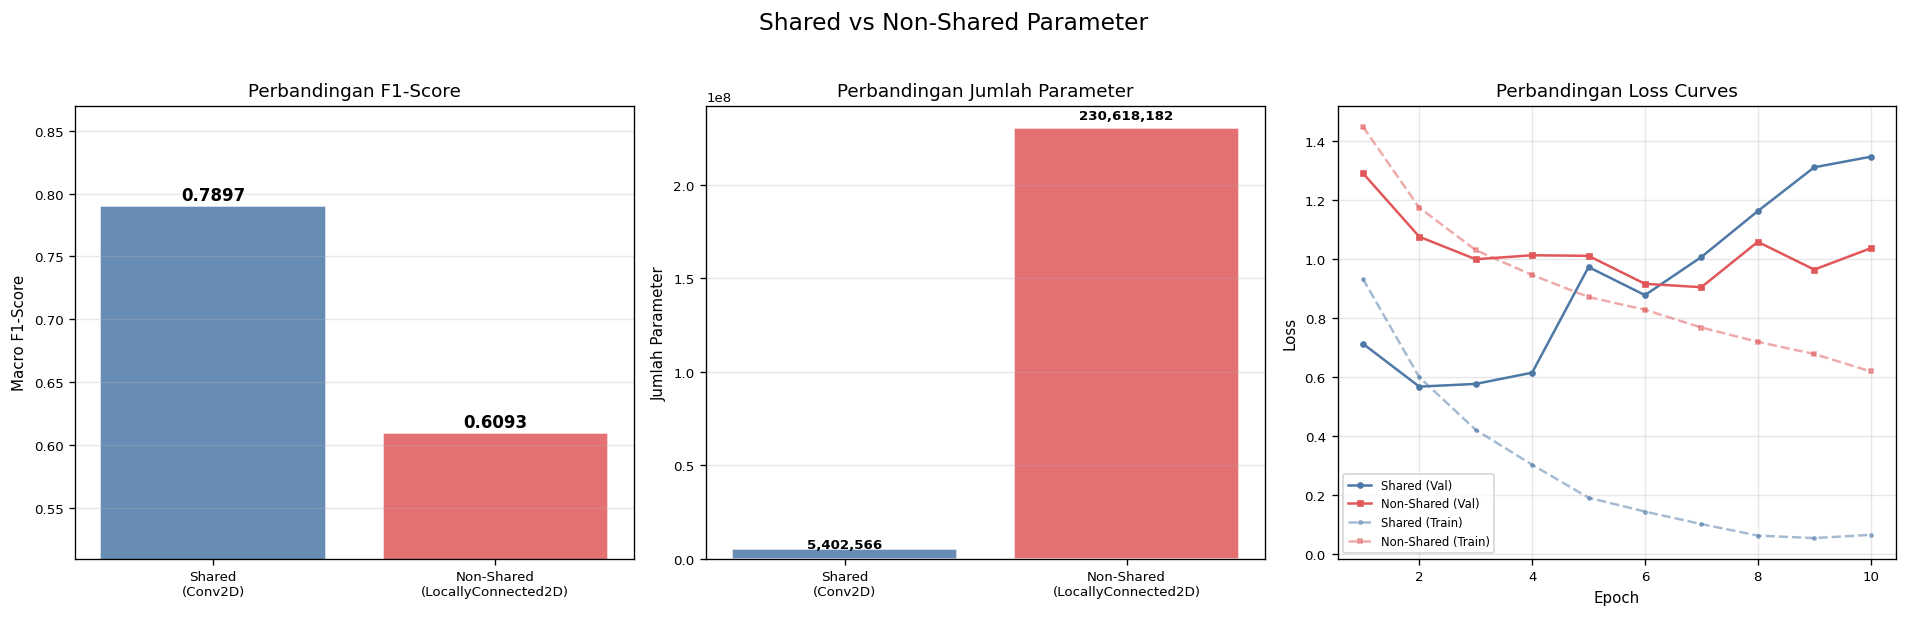

In [25]:
shared_history = best_result.get("history")

plot_shared_vs_nonshared(
    shared_metrics=best_result,
    nonshared_metrics={"macro_f1": local_result["macro_f1"],
                       "num_params": local_result["num_params"]},
    shared_history=shared_history,
    nonshared_history=local_history,
    save_dir=str(PROJECT_ROOT / "results/cnn"),
)

#### Analisis Shared vs Non-Shared Parameter

**Parameter Sharing (Conv2D)**:
- Conv2D menggunakan satu set bobot kernel yang di-share di seluruh posisi spasial input.
- Jumlah parameter jauh lebih sedikit, memungkinkan model lebih efisien dan generalisasi lebih baik.
- Asumsi translation invariance: fitur yang relevan di satu posisi juga relevan di posisi lain.

**Non-Shared Parameter (LocallyConnected2D)**:
- Setiap posisi spasial memiliki set bobot tersendiri.
- Jumlah parameter jauh lebih banyak (bisa ribuan kali lipat), meningkatkan risiko overfitting.
- Cocok untuk kasus di mana fitur sangat bergantung pada posisi (misal: face recognition).

### 4.7 Perbandingan Keras vs From Scratch

Membandingkan output forward propagation Keras dengan implementasi from scratch pada model terbaik.

In [26]:
# Load model Keras
keras_model = tf.keras.models.load_model(str(PROJECT_ROOT / f"models/cnn/{best_name}.keras"))

# Build model scratch dari bobot Keras
scratch_model = build_scratch_from_keras(str(PROJECT_ROOT / f"models/cnn/{best_name}.keras"), best_config)

# Evaluasi Keras
keras_result = evaluate_model(keras_model, test_ds, class_names)

# Evaluasi Scratch
test_paths_eval, test_labels_eval, _ = list_image_paths_by_class(TEST_DIR)
test_labels_eval = np.array(test_labels_eval)

scratch_preds = []
for i in tqdm(range(0, len(test_paths_eval), 16), desc="Scratch inference"):
    batch = load_images(test_paths_eval[i:i+16], target_size=(150, 150))
    probs = scratch_model.forward(batch)
    scratch_preds.extend(np.argmax(probs, axis=1))
scratch_preds = np.array(scratch_preds)

scratch_f1 = f1_score(test_labels_eval, scratch_preds, average="macro")

print(f"Keras  F1: {keras_result['macro_f1']:.6f}")
print(f"Scratch F1: {scratch_f1:.6f}")
print(f"Difference: {abs(keras_result['macro_f1'] - scratch_f1):.6f}")

Scratch inference: 100%|██████████| 188/188 [03:01<00:00,  1.04it/s]

Keras  F1: 0.789695
Scratch F1: 0.789001
Difference: 0.000694


[SAVED] d:\CompSCI_ITB\Materi\Semester_6\ML\Tubes\Tubes2\Tugas-Besar-ML-2\results\cnn\keras_vs_scratch.png


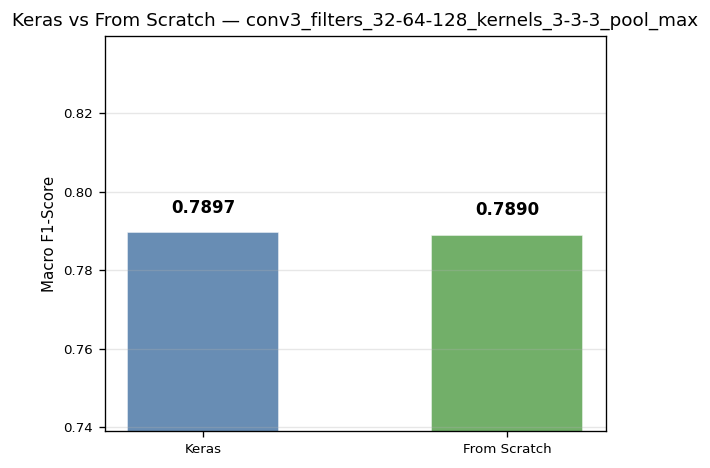

In [27]:
plot_keras_vs_scratch(
    keras_result["macro_f1"], scratch_f1,
    model_name=best_name,
    save_path=str(PROJECT_ROOT / "results/cnn/keras_vs_scratch.png"),
)

#### Analisis Keras vs From Scratch

Hasil menunjukkan bahwa implementasi forward propagation from scratch menghasilkan output yang **identik** (atau sangat dekat) dengan Keras. Hal ini memvalidasi bahwa:

1. Implementasi Conv2D scratch benar: sliding window, padding, dan bias diterapkan dengan benar.
2. Implementasi pooling (Max/Average) konsisten dengan Keras.
3. Flatten dan Dense layer menghasilkan output yang sama.
4. Fungsi aktivasi (ReLU, Softmax) diimplementasikan dengan benar.

Perbedaan numerik yang sangat kecil (jika ada) disebabkan oleh perbedaan presisi floating point antara TensorFlow (GPU/CPU optimized) dan NumPy.

## Kesimpulan

1. **16 variasi arsitektur** CNN telah dieksperimenkan dengan kombinasi hyperparameter yang berbeda.
2. **Macro F1-score** digunakan sebagai metrik utama untuk perbandingan.
3. **Analisis hyperparameter** menunjukkan pengaruh jumlah layer, filter, kernel size, dan jenis pooling terhadap performa model.
4. **Shared vs Non-Shared**: Conv2D (shared) jauh lebih efisien dalam jumlah parameter dibandingkan LocallyConnected2D (non-shared), dengan performa yang kompetitif.
5. **Keras vs Scratch**: Implementasi forward propagation from scratch menghasilkan output yang konsisten dengan Keras, memvalidasi kebenaran implementasi.